# Quantum Teleportation Protocol in PennyLane

In [1]:
import pennylane as qml
import numpy as np
import matplotlib.pyplot as plt

## State Preparation

In [2]:
def state_preparation(state):
    qml.StatePrep(state, wires=[0])

## Arbitrary Unitary Gate


In [3]:
# Define a custom 2x2 unitary matrix (e.g., a rotation around X)
theta = np.pi / 4
U = np.array([[np.cos(theta/2), -1j*np.sin(theta/2)],
              [-1j*np.sin(theta/2), np.cos(theta/2)]])

## Prepare entangled qubits

In [4]:
def entangle_qubits():
    qml.Hadamard(wires=1)
    qml.CNOT(wires=_____)

## Alice operation

In [5]:
def basis_rotation():
    qml.CNOT(wires=_______)
    qml.Hadamard(wires=0)

## Alice measures and Bob conditionally applies gates

In [6]:
def measure_and_update():
    m0 = qml.measure(0)
    m1 = qml.measure(1)
    qml.cond(m1, qml.________)(______)
    qml.cond(m0, qml.________)(______)

## Teleportation Potocol

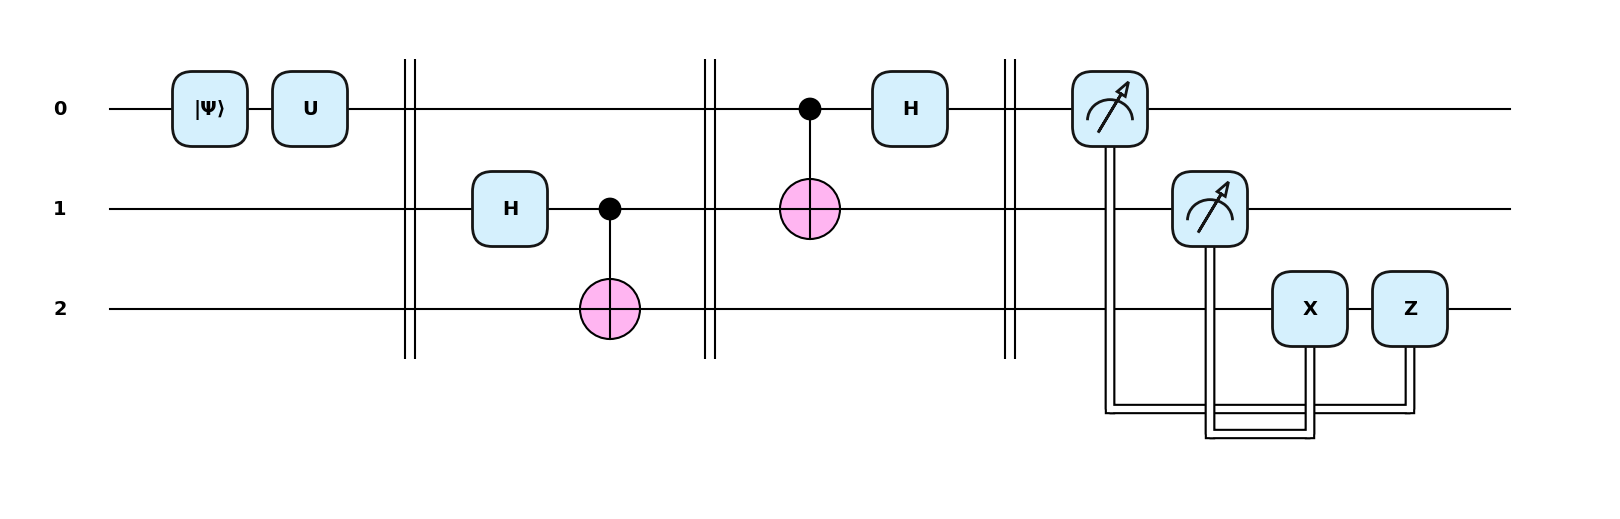

In [29]:
def teleport(state):
    state_preparation(state)
    qml.QubitUnitary(U, wires=_______)
    qml.Barrier()
    entangle_qubits()
    qml.Barrier()
    basis_rotation()
    qml.Barrier()
    measure_and_update()


state = np.array([1, 0])
_ = qml.draw_mpl(teleport, style="pennylane")(state)

In [30]:
probs = teleport(state)

In [31]:
print(probs)

None


## Undo state preparation (to make sure we've teleported the correct state)

In [48]:
def state_undo(state):
    qml.adjoint(qml.StatePrep)(state, wires=[2])

In [69]:
def update():
    qml.CNOT(wires=[1, 2])
    qml.CZ(wires=[0,2])

In [70]:
dev2 = qml.device('default.qubit', wires=[0,1,2])

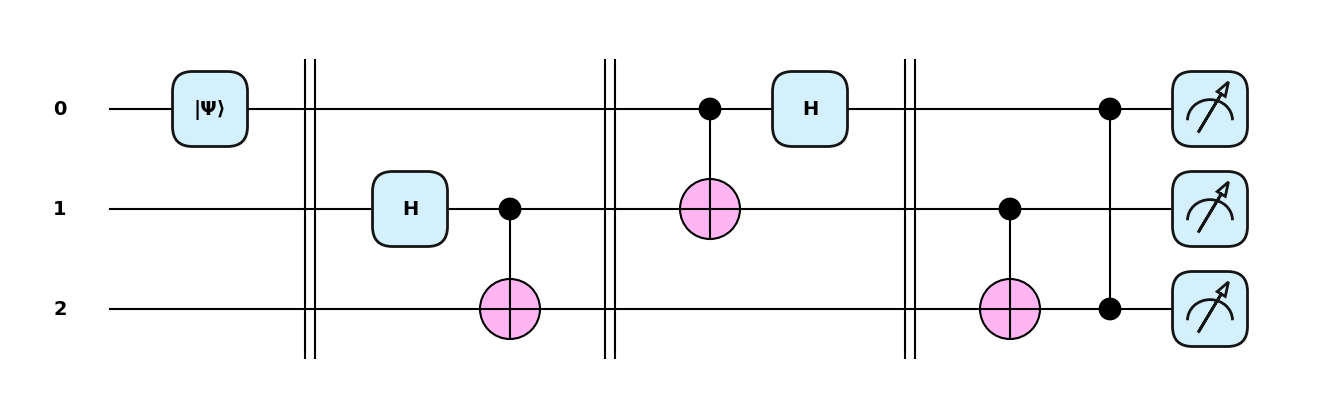

In [89]:
@qml.qnode(dev2)
def teleport(state):
    state_preparation(state)
    qml.Barrier()
    
    # qml.QubitUnitary(U, wires=0)  
    
    entangle_qubits()
    qml.Barrier()
    basis_rotation()
    qml.Barrier()
    update()
    # measure_and_update()

    # qml.adjoint(qml.QubitUnitary)(U, wires=2)  
    # state_undo(state)

    return qml.probs(wires=[0,1,2])

state = np.array([1 , 0])
# state = np.array([0, 1])
# state = np.array([1/np.sqrt(2) ,1/np.sqrt(2)])
# state = np.array([1/np.sqrt(2), 1j/np.sqrt(2)])
_ = qml.draw_mpl(teleport, style="pennylane")(state)

In [90]:
probs = teleport(state)

num_qubits = 3 # change if needed
basis_states = [format(i, f"0{num_qubits}b") for i in range(len(probs))]

for state_label, p in zip(basis_states, probs):
    print(f"{state_label} : {p:.6f}")


000 : 0.250000
001 : 0.000000
010 : 0.250000
011 : 0.000000
100 : 0.250000
101 : 0.000000
110 : 0.250000
111 : 0.000000


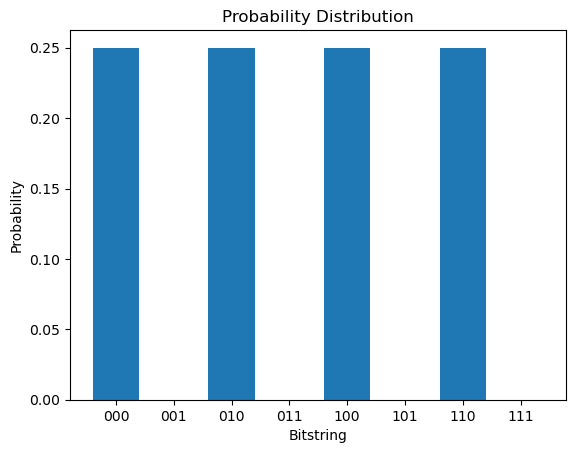

In [91]:
labels = [bin(i)[2:].zfill(3) for i in range(2**3)]  # Convert binary indices to labels
plt.bar(labels, probs)
plt.xlabel("Bitstring")
plt.ylabel("Probability")
plt.title("Probability Distribution")
plt.show()